# The NBA has continued to explore changes to its draft lottery system to discourage tanking, including proposals to further flatten lottery odds.

**A common concern is that reducing draft advantages for the worst teams could make it harder for them to rebuild, potentially trapping them at the bottom of the standings.**

**This project looks at whether that concern is valid by analyzing how long it actually takes lottery teams to return to the playoffs.**

# Key Question

**Do bottom teams remain stuck at the bottom, or do they recover within a reasonable timeframe under the current system?**
To measure recovery, we track the number of years it takes each team to return to the playoffs after a lottery season.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/ismailperacha/nba-tanking-teams-2019-2025/NBA Tanking Dataset - dataset.csv")
df.head()

,season,team,conference,win_pct,wins,losses,league_rank,lottery_seed,actual_pick,pick_jump,had_own_pick,pick_conveyed,pick_team,playoffs_next_year,playoffs_in_2yrs,playoffs_in_3yrs,years_to_playoffs,best_record_next_3yrs,made_playoffs_within_3yrs
0,2018-19,New York Knicks,Eastern,0.207,17,65,30,1,3,-2,1,0,New York Knicks,0,1,0,2.0,0.569,1
1,2018-19,Cleveland Cavaliers,Eastern,0.232,19,63,29,2,5,-3,1,0,Cleveland Cavaliers,0,0,0,4.0,0.537,0
2,2018-19,Phoenix Suns,Western,0.232,19,63,28,3,6,-3,1,0,Minnesota Timberwolves,0,1,1,2.0,0.780,1
3,2018-19,Chicago Bulls,Eastern,0.268,22,60,27,4,7,-3,1,0,Chicago Bulls,0,0,1,3.0,0.561,1
4,2018-19,Atlanta Hawks,Eastern,0.353,29,53,26,5,8,-3,1,0,New Orleans Pelicans,0,1,1,2.0,0.569,1


# Graph 1: Distribution of Recovery Time

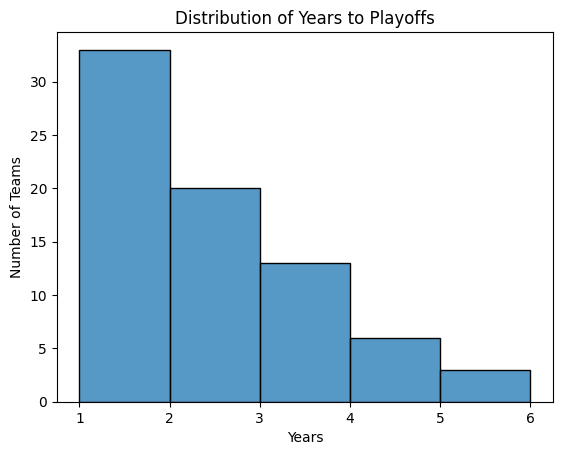

In [5]:
sns.histplot(df['years_to_playoffs'], bins=5)
plt.title("Distribution of Years to Playoffs")
plt.xlabel("Years")
plt.ylabel("Number of Teams")
plt.show()

### Distribution of Recovery Time

Most teams return to the playoffs within a relatively short window, with the majority falling between 1–3 years. While there are some outliers that take longer, extended rebuilds are less common.

This suggests that teams are generally able to recover without remaining at the bottom for long periods.

# Graph 2: By Tier

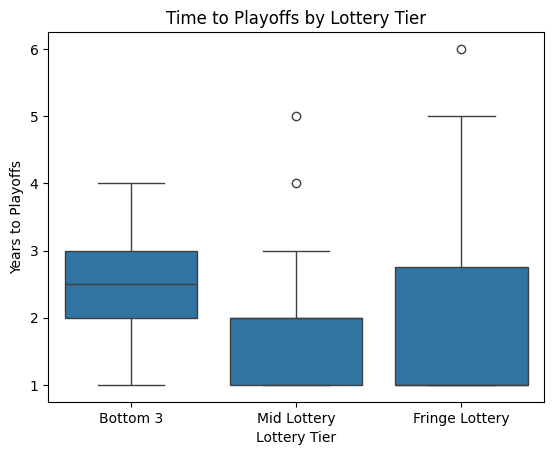

In [11]:
def tier(seed):
    if seed <= 3:
        return "Bottom 3"
    elif seed <= 8:
        return "Mid Lottery"
    else:
        return "Fringe Lottery"

df['tier'] = df['lottery_seed'].apply(tier)

sns.boxplot(
    data=df,
    x='tier',
    y='years_to_playoffs',
    order=['Bottom 3', 'Mid Lottery', 'Fringe Lottery']
)

plt.title("Time to Playoffs by Lottery Tier")
plt.xlabel("Lottery Tier")
plt.ylabel("Years to Playoffs")

plt.show()

### Recovery Time by Team Tier

Bottom-tier teams do take longer to reach the playoffs compared to mid and fringe lottery teams. However, the difference is not extreme—most bottom teams still return within a few years.

This indicates that while being the worst team may slow recovery slightly, it does not significantly delay a team’s ability to become competitive again.

# Graph 3: Cumulative Recovery

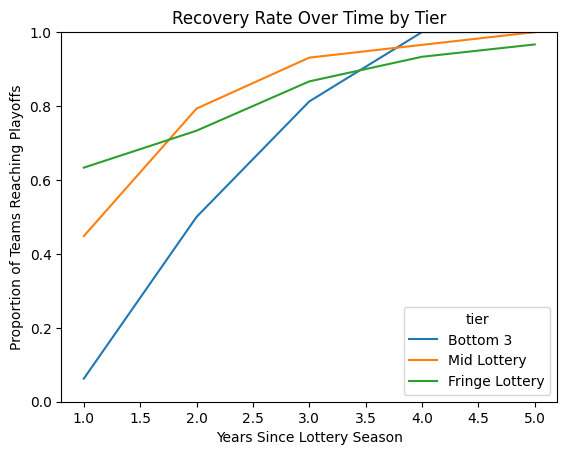

In [17]:
import pandas as pd

results = []

for tier in ['Bottom 3', 'Mid Lottery', 'Fringe Lottery']:
    subset = df[df['tier'] == tier]
    values = subset['years_to_playoffs'].dropna()
    
    for t in range(1,6):
        pct = (values <= t).mean()
        results.append({
            'tier': tier,
            'years': t,
            'pct': pct
        })

cdf = pd.DataFrame(results)

sns.lineplot(data=cdf, x='years', y='pct', hue='tier')

plt.title("Recovery Rate Over Time by Tier")
plt.xlabel("Years Since Lottery Season")
plt.ylabel("Proportion of Teams Reaching Playoffs")

plt.ylim(0,1)
plt.show()

### Recovery Rate Over Time

Over time, the gap between tiers narrows significantly. While bottom teams lag behind in the early years, they catch up as more time passes, with the vast majority reaching the playoffs within 4–5 years.

This reinforces the idea that teams are not permanently stuck at the bottom, even if they start from the worst positions.

# Average Recovery Time

In [19]:
df.groupby('tier')['years_to_playoffs'].mean()

tier
Bottom 3          2.625000
Fringe Lottery    1.866667
Mid Lottery       1.862069
Name: years_to_playoffs, dtype: float64

### Average Time to Playoffs

On average, bottom-tier teams take about 2.6 years to reach the playoffs, compared to roughly 1.9 years for other lottery teams.

While this confirms that worse teams recover more slowly, the difference is relatively small, supporting the idea that recovery timelines are still reasonable across all tiers.

# Final Takeaway

**A common concern with flattening lottery odds is that it could trap the worst teams at the bottom by reducing their ability to rebuild.**

**However, the data suggests that this is not the case. While bottom-tier teams do take slightly longer to return to the playoffs, they are not stuck indefinitely. Most teams across all tiers recover within a relatively short timeframe, typically within 2–4 years.**

**In fact, although bottom teams recover more slowly on average (approx. 2.6 years), the difference compared to other lottery teams (~1.9 years) is modest. Over time, nearly all teams eventually reach the playoffs regardless of their starting position.**

**Overall, this suggests that while tanking does not accelerate success, the current system still allows teams to rebuild effectively. As a result, further flattening of lottery odds may not trap teams at the bottom, but instead reinforce a system where long-term improvement depends more on team-building than draft position alone.**